Building Micrograd - an Autograd engine from Karpathy's "Micrograd" tutorial.

In [1]:
import math 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

In [3]:
xs = np.arange(-5, 5, 0.5)
ys = f(xs)

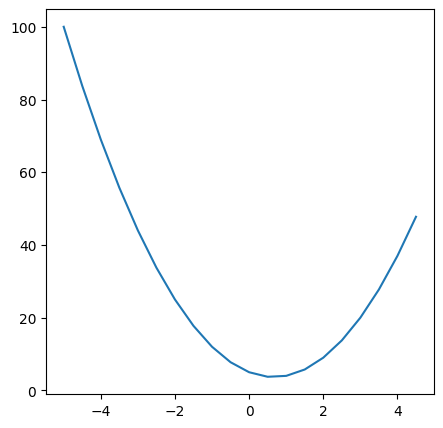

In [4]:
plt.figure(figsize=(5, 5))
plt.plot(xs, ys)

In [5]:
h = 0.00001
x = 2/3
(f(x+h) - f(x))/h

3.0000002482211127e-05

In [6]:
# les get complex hehe
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)

4.0


In [7]:
h = 0.0001
d1 = a*b + c
c += h
d2 = a*b + c

print("d1 is ", d1)
print("d2 is ", d2)

print("slope is ", (d2- d1)/h) 

d1 is  4.0
d2 is  4.0001
slope is  0.9999999999976694


DAY 1 - Done on 5/18/2026 at 19:18 EST

In [51]:
class Value:
    
    def __init__(self, data, _children = (), _op = '', label = ''): # op is string label for the operation that produced a value. 
        self.data = data
        self.grad = 0.0
        self._prev = set(_children)
        self._op = _op
        self.label = label
        
    def __repr__(self):
        return f"Value(data={self.data})"
    
    def __add__(self, other):
        summed = Value(self.data + other.data, (self, other), '+') # this is addition of floats, not of Value objects
        return summed
    
    def __mul__(self, other):
        multiplied = Value(self.data * other.data, (self, other), '*') # the second argument stores the two values that are combined to get the result
        return multiplied
    
    # for activation function
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        return out

a = Value(2.0, label= 'a')
b = Value(-3.0, label= 'b')
c = Value(10.0, label= 'c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label = 'f')
L = d * f; L.label = 'L'
d

Value(data=4.0)

In [23]:
print(d._prev)
d._op

{Value(data=10.0), Value(data=-6.0)}


'+'

In [24]:
from graphviz import Digraph
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for each node, we create a label that shows the operation and the data value
        dot.node(name=uid, label="{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is result of some operation, we create a op node for it
            dot.node(name = uid + n._op, label=n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)
    for n1, n2 in edges:
        # connect n1 to op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
        
    return dot

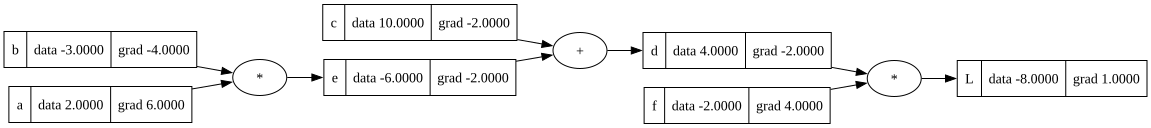

In [44]:
draw_dot(L)

DAY 2 - Done on 5/19/2026 at 18:20 EST 

Starting Day 3 at 15:05 EST on 5/20/2026

d  = c + e

so, dd/dc = 1

dd/de = 1

Now, dL/dc = dL/dd * dd/dc = -2 * 1 = -2

e = a * b
dL/da = dL/de * de/da = -2 * b.data = -2 * -3 = 6

dL/db = dL/de * de/db = -2 * a.data = -2 * 2 = -4

In [43]:
# After writing this, you run the above code again, to see the grad showing up for L. 
# Now, we need to calculate the gradient of L w.r.t other variables (which is usually Loss function w/ weights in NN.)
L.grad = 1.0
f.grad = 4.0
d.grad = -2.0
# writing this later
c.grad = -2.0
e.grad = -2.0
# writing this even later
a.grad = 6.0
b.grad = -4.0

In [48]:
def lol():
    h = 0.0001
    a = Value(2.0, label= 'a')
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label= 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L1 = L.data
    
    a = Value(2.0, label= 'a')
    a.data += h
    b = Value(-3.0, label= 'b')
    c = Value(10.0, label= 'c')
    e = a * b; e.label = 'e'
    d = e + c; d.label = 'd'
    # gradient check
    f = Value(-2.0, label = 'f')
    L = d * f; L.label = 'L'
    L2 = L.data 
    
    print((L2 - L1)/h)
lol()

6.000000000021544


In [56]:
# Backprop ex-2 : through a neuron
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b') # this value is chosen so that the output of the neuron is 1.0 (after activation function)
x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

# now apply activation function
o = n.tanh(); o.label = 'o'


# tanh reduces n to a value between -1 and 1. 

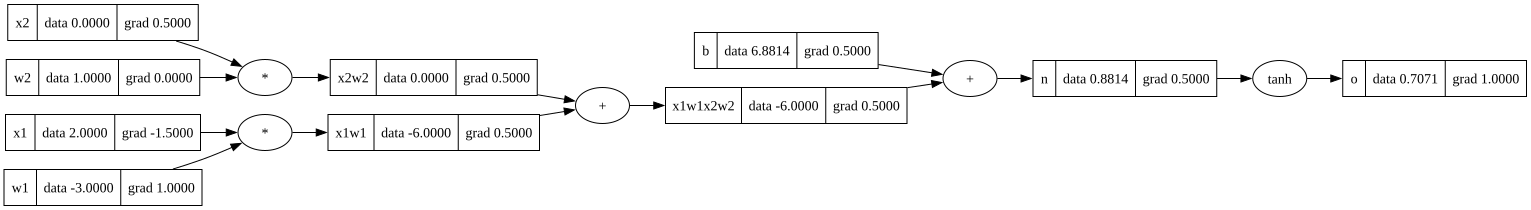

In [69]:
draw_dot(o)

In [71]:
o.grad = 1.0
n.grad = 1 - o.data**2
x1w1x2w2.grad = n.grad * 1.0
b.grad = n.grad * 1.0

# since it's just addition, the gradient of x1w1x2w2 and b is same as n.grad.(Think about it)
x1w1.grad = 0.5
x2w2.grad = 0.5

x2.grad = x2w2.grad * w2.data
w2.grad = x2w2.grad * x2.data # something to notice, since x2 is 0, it's not contributing to the output, so the grad of w2 is also 0.

x1.grad = x1w1.grad * w1.data # here we are finding grad for o w.r.t x1, so we use grad of x1w1 and multiply with w1
w1.grad = x1w1.grad * x1.data

if o = tanh(n)

do/dn = 1 - tanh(n)**2

1 - o.data**2 = 0.499999999

Day 3 - Done on 5/20/2026 at 16:55 EST (1:09:04)